# Region-Based Image Segmentation
### Techniques: Region Growing | Region Splitting | Region Merging | Split and Merge
---

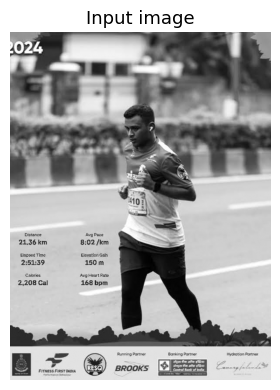

Image shape: (796, 597), dtype: float32, range: [0.00, 1.00]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from collections import deque
from skimage import color, io
import warnings
warnings.filterwarnings('ignore')

# Set your image path here
IMAGE_PATH = 'D:\ippr\experiment_1\image.jpg'

# Load image from disk
IMG = io.imread(IMAGE_PATH)

# Convert to grayscale if image has color channels
if IMG.ndim == 3:
    IMG = color.rgb2gray(IMG)

# Normalize to [0, 1] for the segmentation code below
IMG = IMG.astype(np.float32)
if IMG.max() > 1.0:
    IMG = IMG / 255.0

plt.figure(figsize=(4, 4))
plt.imshow(IMG, cmap='gray', vmin=0, vmax=1)
plt.title('Input image', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()
print(f'Image shape: {IMG.shape}, dtype: {IMG.dtype}, range: [{IMG.min():.2f}, {IMG.max():.2f}]')

---
## 1. Region Growing

**Concept:**  
Start from one or more *seed* pixels. Recursively examine the 4-connected neighbours of every accepted pixel; absorb a neighbour into the current region if its intensity lies within `[seed_val - threshold, seed_val + threshold]`.  
Connectivity prevents bridging across unrelated parts of the image, while the threshold controls how much intensity variation is tolerated.

**Algorithm steps:**
1. Mark seed pixel → add to queue
2. Pop pixel from queue, inspect 4-neighbours
3. For each unvisited neighbour: if `|I(neighbour) - I(seed)| ≤ T` → assign to region, enqueue
4. Repeat until queue is empty

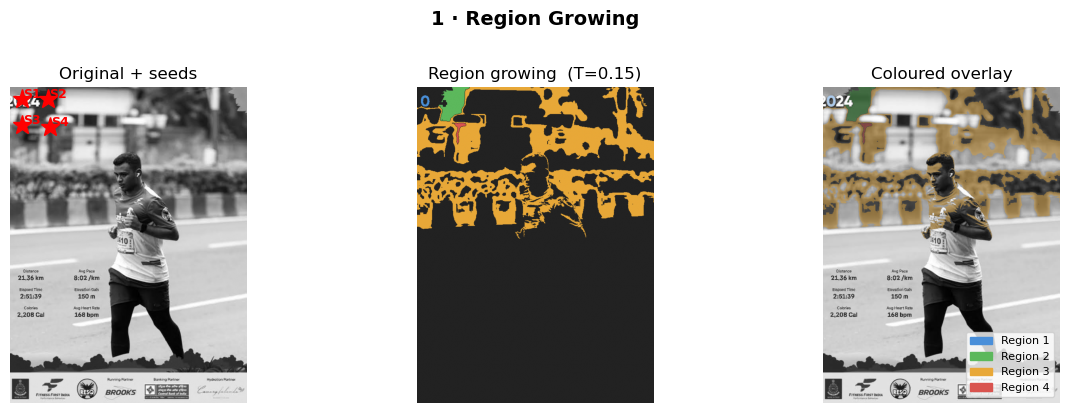

Pixels assigned  : 85,052  |  Unassigned: 390,160
  Region 1: 351 pixels
  Region 2: 3,797 pixels
  Region 3: 80,523 pixels
  Region 4: 381 pixels


In [2]:
def region_growing(image, seeds, threshold=0.12):
    """
    Region Growing Segmentation.

    Parameters
    ----------
    image     : 2-D float array, values in [0, 1]
    seeds     : list of (row, col) tuples – one seed per desired region
    threshold : max absolute intensity difference to absorb a neighbour

    Returns
    -------
    labels    : 2-D int array; 0 = unassigned, 1..N = region ids
    """
    rows, cols = image.shape
    labels     = np.zeros((rows, cols), dtype=np.int32)
    visited    = np.zeros((rows, cols), dtype=bool)
    neighbours = [(-1, 0), (1, 0), (0, -1), (0, 1)]   # 4-connectivity

    for region_id, (sr, sc) in enumerate(seeds, start=1):
        seed_val = image[sr, sc]
        queue    = deque([(sr, sc)])
        visited[sr, sc]  = True
        labels[sr, sc]   = region_id

        while queue:
            r, c = queue.popleft()
            for dr, dc in neighbours:
                nr, nc = r + dr, c + dc
                if 0 <= nr < rows and 0 <= nc < cols and not visited[nr, nc]:
                    visited[nr, nc] = True
                    if abs(image[nr, nc] - seed_val) <= threshold:
                        labels[nr, nc] = region_id
                        queue.append((nr, nc))

    return labels


# ── Run ───────────────────────────────────────────────────────────────────────
SEEDS = [(30, 30), (30, 95), (95, 30), (100, 100)]   # one per synthetic region
THRESHOLD = 0.15

rg_labels = region_growing(IMG, SEEDS, threshold=THRESHOLD)

# ── Visualise ─────────────────────────────────────────────────────────────────
n_regions = len(SEEDS)
cmap = ListedColormap(['#222222', '#4A90D9', '#5CB85C', '#E8A838', '#D9534F'])

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].imshow(IMG, cmap='gray')
for i, (r, c) in enumerate(SEEDS):
    axes[0].plot(c, r, 'r*', markersize=14)
    axes[0].text(c+3, r-4, f'S{i+1}', color='red', fontsize=9, fontweight='bold')
axes[0].set_title('Original + seeds', fontsize=12)
axes[0].axis('off')

axes[1].imshow(rg_labels, cmap=cmap, vmin=0, vmax=n_regions)
axes[1].set_title(f'Region growing  (T={THRESHOLD})', fontsize=12)
axes[1].axis('off')

overlay = np.stack([IMG]*3, axis=-1)
region_colours = [[0.29, 0.56, 0.85], [0.36, 0.72, 0.36],
                  [0.91, 0.66, 0.22], [0.85, 0.33, 0.31]]
alpha = 0.45
for rid in range(1, n_regions+1):
    mask = (rg_labels == rid)
    for ch in range(3):
        overlay[:,:,ch][mask] = (1-alpha)*overlay[:,:,ch][mask] + alpha*region_colours[rid-1][ch]
axes[2].imshow(overlay)
patches = [mpatches.Patch(color=region_colours[i], label=f'Region {i+1}')
           for i in range(n_regions)]
axes[2].legend(handles=patches, loc='lower right', fontsize=8, framealpha=0.8)
axes[2].set_title('Coloured overlay', fontsize=12)
axes[2].axis('off')

plt.suptitle('1 · Region Growing', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

unassigned = np.sum(rg_labels == 0)
print(f'Pixels assigned  : {np.sum(rg_labels > 0):,}  |  Unassigned: {unassigned:,}')
for i in range(1, n_regions+1):
    print(f'  Region {i}: {np.sum(rg_labels==i):,} pixels')

---
## 2. Region Splitting

**Concept:**  
Begin with the whole image as one region. Recursively **split** any region whose pixels are not homogeneous (i.e. the intensity range exceeds a threshold) into four equal quadrants (quadtree decomposition). Continue until every leaf region is homogeneous or reaches the minimum block size.

**Algorithm steps:**
1. Start: single region = entire image
2. Test homogeneity: `max(I) - min(I) ≤ T` in the block
3. If **not** homogeneous and block > min_size → split into 4 quadrants, recurse
4. Assign each leaf block a uniform label (its mean intensity)

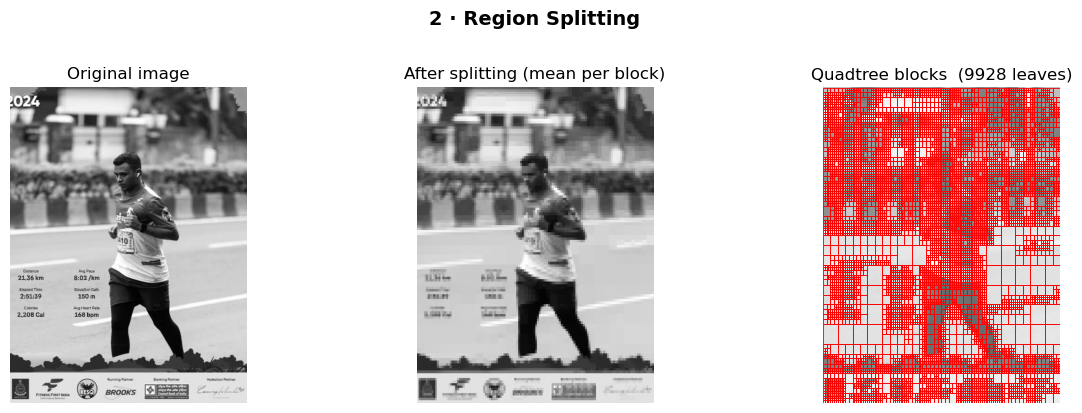

Total leaf blocks: 9928
Block pixel sizes – min: 24, max: 1900, mean: 47.9


In [3]:
def region_splitting(image, threshold=0.12, min_size=4):
    """
    Quadtree Region Splitting.

    Parameters
    ----------
    image     : 2-D float array
    threshold : max intensity range (max-min) for a block to be homogeneous
    min_size  : smallest allowed block side (pixels)

    Returns
    -------
    labels    : 2-D float array – each pixel set to its block's mean intensity
    blocks    : list of (r0, c0, r1, c1) leaf block extents
    """
    rows, cols = image.shape
    result     = np.zeros_like(image)
    blocks     = []

    def is_homogeneous(r0, c0, r1, c1):
        patch = image[r0:r1, c0:c1]
        return (patch.max() - patch.min()) <= threshold

    def split(r0, c0, r1, c1):
        h = r1 - r0
        w = c1 - c0
        if is_homogeneous(r0, c0, r1, c1) or h < min_size * 2 or w < min_size * 2:
            mean_val = image[r0:r1, c0:c1].mean()
            result[r0:r1, c0:c1] = mean_val
            blocks.append((r0, c0, r1, c1))
        else:
            rm, cm = (r0 + r1) // 2, (c0 + c1) // 2
            split(r0, c0, rm, cm)
            split(r0, cm, rm, c1)
            split(rm, c0, r1, cm)
            split(rm, cm, r1, c1)

    split(0, 0, rows, cols)
    return result, blocks


# ── Run ───────────────────────────────────────────────────────────────────────
import sys; sys.setrecursionlimit(50000)

split_result, split_blocks = region_splitting(IMG, threshold=0.12, min_size=4)

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].imshow(IMG, cmap='gray')
axes[0].set_title('Original image', fontsize=12)
axes[0].axis('off')

axes[1].imshow(split_result, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('After splitting (mean per block)', fontsize=12)
axes[1].axis('off')

axes[2].imshow(IMG, cmap='gray', alpha=0.6)
for (r0, c0, r1, c1) in split_blocks:
    rect = mpatches.Rectangle((c0, r0), c1-c0, r1-r0,
                               linewidth=0.6, edgecolor='red', facecolor='none')
    axes[2].add_patch(rect)
axes[2].set_title(f'Quadtree blocks  ({len(split_blocks)} leaves)', fontsize=12)
axes[2].axis('off')

plt.suptitle('2 · Region Splitting', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Total leaf blocks: {len(split_blocks)}')
sizes = [(r1-r0)*(c1-c0) for r0,c0,r1,c1 in split_blocks]
print(f'Block pixel sizes – min: {min(sizes)}, max: {max(sizes)}, mean: {np.mean(sizes):.1f}')

---
## 3. Region Merging

**Concept:**  
Start with many small atomic regions (here: each pixel is its own region, or tiny blocks after an initial over-segmentation). Iteratively **merge** adjacent regions whose mean intensities are close (difference ≤ threshold). This is a bottom-up, agglomerative approach.

**Algorithm steps:**
1. Initialise: label every pixel uniquely (or use small seed blocks)
2. Build adjacency list for all region pairs that share a border
3. For each adjacent pair: if `|mean(R_i) - mean(R_j)| ≤ T` → merge (union-find)
4. Repeat until no more merges occur

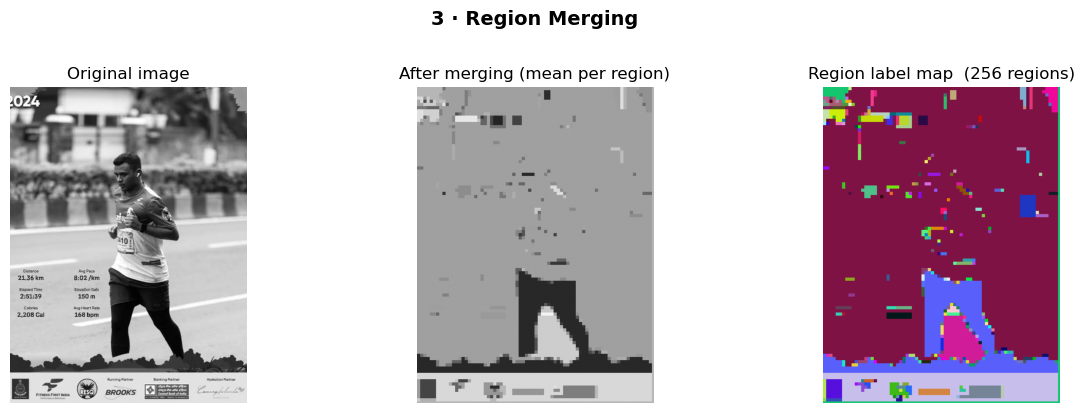

Regions after merging: 256


In [4]:
def region_merging(image, threshold=0.10, block_size=8):
    """
    Region Merging via Union-Find.

    Parameters
    ----------
    image      : 2-D float array
    threshold  : max mean-intensity difference to merge two adjacent regions
    block_size : initial atomic block side (pixels); avoids pixel-level cost

    Returns
    -------
    label_img  : 2-D int array with final region labels
    """
    rows, cols = image.shape
    br = rows // block_size
    bc = cols // block_size

    # ── Compute mean per block ────────────────────────────────────────────────
    block_means = np.zeros((br, bc), dtype=np.float32)
    for r in range(br):
        for c in range(bc):
            block_means[r, c] = image[r*block_size:(r+1)*block_size,
                                       c*block_size:(c+1)*block_size].mean()

    total = br * bc

    # ── Union-Find ────────────────────────────────────────────────────────────
    parent = list(range(total))
    rank   = [0] * total

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(x, y):
        px, py = find(x), find(y)
        if px == py:
            return
        if rank[px] < rank[py]:
            px, py = py, px
        parent[py] = px
        if rank[px] == rank[py]:
            rank[px] += 1

    # ── Merge pass ────────────────────────────────────────────────────────────
    changed = True
    while changed:
        changed = False
        for r in range(br):
            for c in range(bc):
                idx = r * bc + c
                for dr, dc in [(0, 1), (1, 0)]:   # right & down
                    nr, nc = r + dr, c + dc
                    if 0 <= nr < br and 0 <= nc < bc:
                        nidx = nr * bc + nc
                        if find(idx) != find(nidx):
                            if abs(block_means[r, c] - block_means[nr, nc]) <= threshold:
                                union(idx, nidx)
                                changed = True

    # ── Build compact label image ─────────────────────────────────────────────
    label_img = np.zeros((rows, cols), dtype=np.int32)
    root_map  = {}
    counter   = 0
    for r in range(br):
        for c in range(bc):
            root = find(r * bc + c)
            if root not in root_map:
                root_map[root] = counter
                counter += 1
            lbl = root_map[root]
            label_img[r*block_size:(r+1)*block_size,
                       c*block_size:(c+1)*block_size] = lbl

    return label_img, counter


# ── Run ───────────────────────────────────────────────────────────────────────
merge_labels, n_merge_regions = region_merging(IMG, threshold=0.10, block_size=8)

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].imshow(IMG, cmap='gray')
axes[0].set_title('Original image', fontsize=12)
axes[0].axis('off')

# Mean-colour rendering
merged_viz = np.zeros_like(IMG)
for lbl in range(n_merge_regions):
    mask = merge_labels == lbl
    if mask.any():
        merged_viz[mask] = IMG[mask].mean()
axes[1].imshow(merged_viz, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('After merging (mean per region)', fontsize=12)
axes[1].axis('off')

np.random.seed(7)
rand_cmap = ListedColormap(np.random.rand(n_merge_regions + 1, 3))
axes[2].imshow(merge_labels, cmap=rand_cmap)
axes[2].set_title(f'Region label map  ({n_merge_regions} regions)', fontsize=12)
axes[2].axis('off')

plt.suptitle('3 · Region Merging', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Regions after merging: {n_merge_regions}')

---
## 4. Split and Merge

**Concept:**  
Combines both strategies. First **split** the image recursively (quadtree) until each block is homogeneous. Then **merge** adjacent leaf blocks that have similar mean intensities. This corrects over-segmentation left by pure splitting.

**Algorithm steps:**
1. **Split phase**: quadtree until all blocks homogeneous (same as §2)
2. **Merge phase**: build adjacency graph of leaf blocks; iteratively merge neighbours with similar means
3. Assign each pixel the label of its final merged super-block

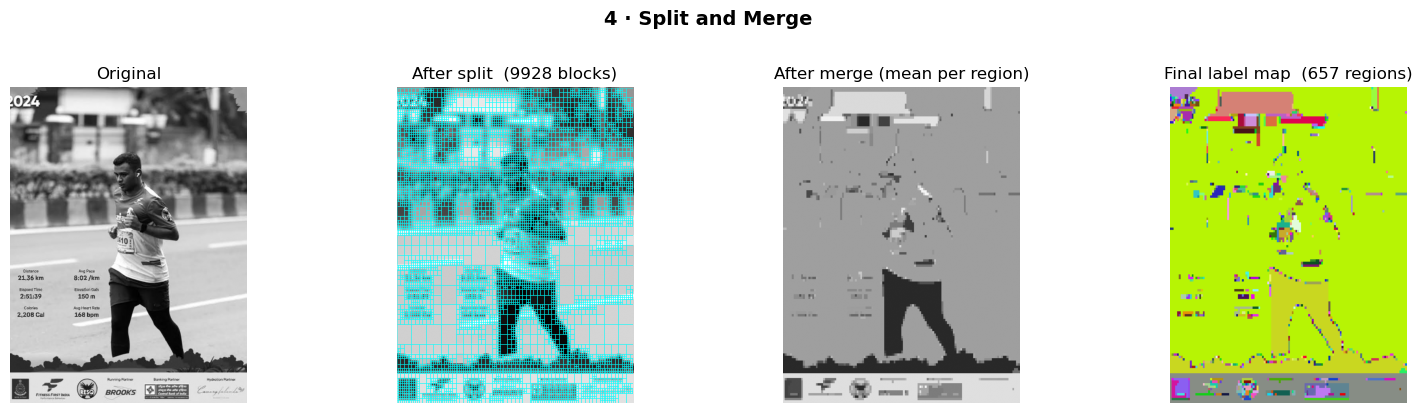

Blocks after split : 9928
Regions after merge: 657


In [5]:
def split_and_merge(image, split_threshold=0.12, merge_threshold=0.08, min_size=4):
    """
    Split-and-Merge Segmentation.

    Parameters
    ----------
    image            : 2-D float array
    split_threshold  : homogeneity criterion for splitting (max range)
    merge_threshold  : similarity criterion for merging (max mean diff)
    min_size         : smallest block side

    Returns
    -------
    label_img    : 2-D int array with final segment labels
    split_blocks : leaf blocks after splitting
    n_regions    : number of final regions after merging
    """
    rows, cols = image.shape

    # ── Phase 1: Split ────────────────────────────────────────────────────────
    block_id_img = np.full((rows, cols), -1, dtype=np.int32)
    block_list   = []   # [(r0,c0,r1,c1), ...]

    def is_homo(r0, c0, r1, c1):
        p = image[r0:r1, c0:c1]
        return (p.max() - p.min()) <= split_threshold

    def split(r0, c0, r1, c1):
        h, w = r1 - r0, c1 - c0
        if is_homo(r0, c0, r1, c1) or h < min_size*2 or w < min_size*2:
            bid = len(block_list)
            block_list.append((r0, c0, r1, c1))
            block_id_img[r0:r1, c0:c1] = bid
        else:
            rm, cm = (r0+r1)//2, (c0+c1)//2
            split(r0, c0, rm, cm)
            split(r0, cm, rm, c1)
            split(rm, c0, r1, cm)
            split(rm, cm, r1, c1)

    split(0, 0, rows, cols)
    n_blocks = len(block_list)

    # ── Phase 2: Merge via Union-Find ─────────────────────────────────────────
    block_means = np.array([image[r0:r1, c0:c1].mean()
                             for r0, c0, r1, c1 in block_list])

    parent = list(range(n_blocks))
    rank   = [0] * n_blocks

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        pa, pb = find(a), find(b)
        if pa == pb: return
        if rank[pa] < rank[pb]: pa, pb = pb, pa
        parent[pb] = pa
        if rank[pa] == rank[pb]: rank[pa] += 1

    # Build adjacency via border pixels
    adj = set()
    for r in range(rows):
        for c in range(cols-1):
            a, b = block_id_img[r, c], block_id_img[r, c+1]
            if a != b: adj.add((min(a,b), max(a,b)))
    for r in range(rows-1):
        for c in range(cols):
            a, b = block_id_img[r, c], block_id_img[r+1, c]
            if a != b: adj.add((min(a,b), max(a,b)))

    changed = True
    while changed:
        changed = False
        for a, b in list(adj):
            if find(a) != find(b):
                if abs(block_means[a] - block_means[b]) <= merge_threshold:
                    union(a, b)
                    changed = True

    # ── Build output ──────────────────────────────────────────────────────────
    label_img = np.zeros((rows, cols), dtype=np.int32)
    root_map, counter = {}, 0
    for bid, (r0, c0, r1, c1) in enumerate(block_list):
        root = find(bid)
        if root not in root_map:
            root_map[root] = counter
            counter += 1
        label_img[r0:r1, c0:c1] = root_map[root]

    return label_img, block_list, counter


# ── Run ───────────────────────────────────────────────────────────────────────
sm_labels, sm_blocks, n_sm = split_and_merge(
    IMG, split_threshold=0.12, merge_threshold=0.08, min_size=4)

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(IMG, cmap='gray')
axes[0].set_title('Original', fontsize=12)
axes[0].axis('off')

# Split only
split_only, _ = region_splitting(IMG, threshold=0.12, min_size=4)
axes[1].imshow(split_only, cmap='gray', vmin=0, vmax=1)
for (r0,c0,r1,c1) in sm_blocks:
    rect = mpatches.Rectangle((c0,r0),c1-c0,r1-r0,
                               linewidth=0.5,edgecolor='cyan',facecolor='none',alpha=0.5)
    axes[1].add_patch(rect)
axes[1].set_title(f'After split  ({len(sm_blocks)} blocks)', fontsize=12)
axes[1].axis('off')

# Mean-colour after merge
sm_mean_img = np.zeros_like(IMG)
for lbl in range(n_sm):
    mask = sm_labels == lbl
    if mask.any():
        sm_mean_img[mask] = IMG[mask].mean()
axes[2].imshow(sm_mean_img, cmap='gray', vmin=0, vmax=1)
axes[2].set_title('After merge (mean per region)', fontsize=12)
axes[2].axis('off')

np.random.seed(99)
sm_cmap = ListedColormap(np.random.rand(n_sm+1, 3))
axes[3].imshow(sm_labels, cmap=sm_cmap)
axes[3].set_title(f'Final label map  ({n_sm} regions)', fontsize=12)
axes[3].axis('off')

plt.suptitle('4 · Split and Merge', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Blocks after split : {len(sm_blocks)}')
print(f'Regions after merge: {n_sm}')

---
## 5. Side-by-Side Comparison

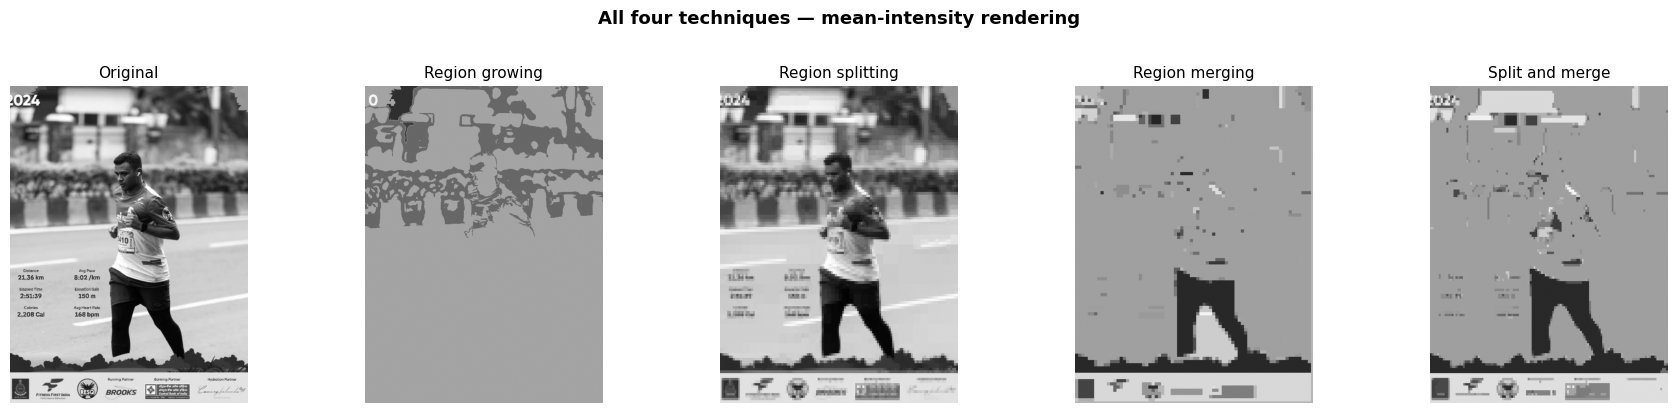


─── Summary ───────────────────────────────────────────────────────
Technique              # Regions      Approach
─────────────────────────────────────────────────────────────────
Region growing         4              Bottom-up from seeds (BFS)
Region splitting       9928           Top-down quadtree
Region merging         256            Bottom-up union-find
Split and merge        657            Quadtree split → union-find merge
─────────────────────────────────────────────────────────────────


In [6]:
# ── Build mean-colour images for every method ─────────────────────────────────
def mean_colour_img(image, labels, n):
    out = np.zeros_like(image)
    for lbl in range(n):
        mask = labels == lbl
        if mask.any(): out[mask] = image[mask].mean()
    return out

# Region Growing – build a mean image from labels
rg_mean = mean_colour_img(IMG, rg_labels, rg_labels.max()+1)

# Region Splitting – already have split_result

# Region Merging
rm_mean = mean_colour_img(IMG, merge_labels, n_merge_regions)

# Split & Merge
sm_mean = mean_colour_img(IMG, sm_labels, n_sm)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
titles = ['Original', 'Region growing', 'Region splitting',
          'Region merging', 'Split and merge']
imgs   = [IMG, rg_mean, split_result, rm_mean, sm_mean]

for ax, im, t in zip(axes, imgs, titles):
    ax.imshow(im, cmap='gray', vmin=0, vmax=1)
    ax.set_title(t, fontsize=11)
    ax.axis('off')

plt.suptitle('All four techniques — mean-intensity rendering', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print('\n─── Summary ───────────────────────────────────────────────────────')
print(f'{"Technique":<22} {"# Regions":<14} {"Approach"}')
print('─' * 65)
print(f'{"Region growing":<22} {rg_labels.max():<14} Bottom-up from seeds (BFS)')
print(f'{"Region splitting":<22} {len(split_blocks):<14} Top-down quadtree')
print(f'{"Region merging":<22} {n_merge_regions:<14} Bottom-up union-find')
print(f'{"Split and merge":<22} {n_sm:<14} Quadtree split → union-find merge')
print('─' * 65)